<a href="https://colab.research.google.com/github/Matheusfelipeg/Atividade_02/blob/main/ETL_Analise_Vendas_Python_24072026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Projeto ETL - Tratamento e Análise de Dados de Vendas

## Contexto

Uma empresa do setor de tecnologia disponibilizou duas bases de dados contendo o histórico de vendas e as metas comerciais dos gerentes das lojas. O objetivo deste projeto é aplicar um processo completo de ETL para preparar essas informações, gerar novos conjuntos de dados e produzir análises que apoiem a tomada de decisão.

## Objetivo

Este projeto tem como objetivo demonstrar a aplicação do processo de **ETL (Extract, Transform and Load)** utilizando Python e Pandas. Durante o desenvolvimento foram realizadas etapas de extração, limpeza, padronização, enriquecimento dos dados e geração de análises, simulando atividades comuns na rotina de um Analista de Dados.


## 📚 Importação das bibliotecas

Nesta etapa são importadas as bibliotecas necessárias para o desenvolvimento do projeto. O **Pandas** é utilizado para leitura, manipulação e análise dos dados, enquanto o **NumPy** auxilia na criação de regras condicionais e operações vetorizadas durante o processo de transformação.

In [220]:
import pandas as pd
import numpy as np

## 📥 Extração dos dados

Os dados foram carregados a partir de duas fontes distintas:

- **Base de vendas:** contém o histórico de pedidos realizados pela empresa.
- **Base de gerentes:** contém as informações dos gerentes responsáveis por cada loja e suas respectivas metas mensais.

Após a importação, é realizada uma inspeção inicial da base para verificar sua estrutura e garantir que os dados foram carregados corretamente.

In [221]:
df_vendas = pd.read_csv('/content/drive/MyDrive/Projeto ETL Python 1 - 22072026/Projeto ETL Completo_ ETL e Configurações iniciais - vendas_tech.csv', low_memory= False)
df_gerentes = pd.read_excel('/content/drive/MyDrive/Projeto ETL Python 1 - 22072026/Projeto ETL Completo_ ETL e Configurações iniciais - gerentes_lojas.xlsx')


In [222]:
display(df_vendas.head())
display(df_vendas.info())

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Data_Base
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095,2025-01-01
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750,NaN
2,3,2023-02-25,NaN,"Monitor 27""",1200.0,1,Cliente_14859,NaN
3,4,2024-11-19,RIO DE JANEIRO,Mouse Gamer,120.0,2,Cliente_17343,NaN
4,5,2024-01-27,Rio de Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100100 entries, 0 to 100099
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   ID_Pedido       100100 non-null  int64  
 1   Data            100100 non-null  object 
 2   Loja            98099 non-null   object 
 3   Produto         100100 non-null  object 
 4   Preco_Unitario  100100 non-null  float64
 5   Qtd             100100 non-null  int64  
 6   Cliente         100100 non-null  object 
 7   Data_Base       1 non-null       object 
dtypes: float64(1), int64(2), object(5)
memory usage: 6.1+ MB


None

In [223]:
display(df_gerentes.head())
display(df_gerentes.info())

,Loja,Gerente,Meta_Mensal
0,São Paulo,Carlos,50000
1,Rio de Janeiro,Fernanda,60000
2,Curitiba,Roberto,45000
3,Belo Horizonte,Juliana,55000
4,Recife,Marcos,48000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Loja         7 non-null      object
 1   Gerente      7 non-null      object
 2   Meta_Mensal  7 non-null      int64 
dtypes: int64(1), object(2)
memory usage: 300.0+ bytes


None

## Transformação dos dados

Nesta etapa foi realizado o tratamento da base de dados com o objetivo de garantir maior qualidade e consistência das informações antes das análises.

As principais transformações realizadas foram:

- Remoção de colunas desnecessárias;
- Tratamento de valores ausentes;
- Conversão da coluna de datas para o formato `datetime`;
- Padronização dos nomes das lojas e produtos;
- Remoção de registros duplicados;
- Criação de novas variáveis para enriquecer a base de dados.

Essas transformações tornam os dados mais confiáveis e preparados para as etapas seguintes do processo ETL.

In [224]:
df_vendas = df_vendas.drop(columns=['Data_Base'])

df_vendas['Loja'] = df_vendas['Loja'].fillna('Online')


df_vendas['Data'] = pd.to_datetime(df_vendas['Data'], format= '%Y-%m-%d')

df_vendas['Loja'] = df_vendas['Loja'].str.strip().str.title()
df_vendas['Produto'] = df_vendas['Produto'].str.strip().str.title()

df_gerentes['Loja'] = df_gerentes['Loja'].str.strip().str.title()

df_vendas = df_vendas.drop_duplicates(subset= ['ID_Pedido'])


## 📌 Criação de novas variáveis

Além da limpeza dos dados, foram criadas novas colunas que facilitam as análises realizadas posteriormente.

As variáveis adicionadas foram:

- **Faturamento:** cálculo realizado multiplicando a quantidade vendida pelo preço unitário;
- **Forma de venda:** classificação automática entre vendas presenciais e online;
- **Região:** identificação da região do país correspondente a cada loja por meio de um dicionário de mapeamento.


In [225]:
df_vendas['Faturamento'] = df_vendas['Qtd'] * df_vendas['Preco_Unitario']

df_vendas['forma_venda'] = np.where(df_vendas['Loja'] == 'Online', 'Online','Presencial')

dic_regioes = {
    "Rio Branco": "Norte",
    "Maceió": "Nordeste",
    "Macapá": "Norte",
    "Manaus": "Norte",
    "Salvador": "Nordeste",
    "Fortaleza": "Nordeste",
    "Brasília": "Centro-Oeste",
    "Vitória": "Sudeste",
    "Goiânia": "Centro-Oeste",
    "São Luís": "Nordeste",
    "Cuiabá": "Centro-Oeste",
    "Campo Grande": "Centro-Oeste",
    "Belo Horizonte": "Sudeste",
    "Belém": "Norte",
    "João Pessoa": "Nordeste",
    "Curitiba": "Sul",
    "Recife": "Nordeste",
    "Teresina": "Nordeste",
    "Rio De Janeiro": "Sudeste",
    "Natal": "Nordeste",
    "Porto Alegre": "Sul",
    "Porto Velho": "Norte",
    "Boa Vista": "Norte",
    "Florianópolis": "Sul",
    "São Paulo": "Sudeste",
    "Aracaju": "Nordeste",
    "Palmas": "Norte",
    "Online": "Online"
}

df_vendas['Região'] = df_vendas['Loja'].map(dic_regioes)

display(df_vendas)


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,forma_venda,Região
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095,120.0,Presencial,Sudeste
1,2,2023-03-01,Belo Horizonte,Iphone 14,5500.0,1,Cliente_8750,5500.0,Presencial,Sudeste
2,3,2023-02-25,Online,"Monitor 27""",1200.0,1,Cliente_14859,1200.0,Online,Online
3,4,2024-11-19,Rio De Janeiro,Mouse Gamer,120.0,2,Cliente_17343,240.0,Presencial,Sudeste
4,5,2024-01-27,Rio De Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377,2200.0,Presencial,Sudeste
...,...,...,...,...,...,...,...,...,...,...
99995,99996,2023-01-24,São Paulo,Mouse Gamer,120.0,2,Cliente_13732,240.0,Presencial,Sudeste
99996,99997,2024-08-28,Rio De Janeiro,Cabo Hdmi,40.0,1,Cliente_25058,40.0,Presencial,Sudeste
99997,99998,2024-03-18,Curitiba,Smartphone Samsung,2200.0,2,Cliente_28864,4400.0,Presencial,Sul
99998,99999,2023-11-04,Porto Alegre,Iphone 14,5500.0,1,Cliente_4205,5500.0,Presencial,Sul


## 📤 Carga dos dados (Load)

Como etapa final do processo de ETL, foram gerados novos arquivos contendo subconjuntos específicos da base tratada.

Foram exportados:

- Um arquivo contendo apenas as vendas realizadas na loja de **São Paulo**;
- Um arquivo contendo apenas os registros de vendas referentes ao ano de **2024**.



In [234]:
df_vendas_sp = df_vendas.loc[df_vendas['Loja'] == 'São Paulo', :]
df_vendas_sp.to_csv('Vendas_SP.csv', index= False)

df_vendas_2024 = df_vendas[df_vendas['Data'].dt.year == 2024]
df_vendas_2024.to_csv('Vendas_2024.csv', index= False)


## 📈 Análise 1 - Faturamento por loja

Nesta análise foi calculado o faturamento total de cada loja, permitindo identificar quais unidades apresentaram o melhor desempenho financeiro.

Os dados foram agrupados por loja, somando o faturamento de todos os pedidos e organizando os resultados em ordem decrescente.

In [227]:
analise_vendas = df_vendas[['Loja','Faturamento']].groupby('Loja').sum().sort_values(by= 'Faturamento', ascending= False).reset_index()

def formatar(valor):
  valor = f'R$ {valor:,.2f}'
  return valor

analise_vendas['Faturamento'] = analise_vendas['Faturamento'].apply(formatar)



display(analise_vendas)

,Loja,Faturamento
0,Salvador,"R$ 42,300,610.00"
1,Rio De Janeiro,"R$ 42,294,720.00"
2,Recife,"R$ 42,190,390.00"
3,São Paulo,"R$ 42,090,690.00"
4,Belo Horizonte,"R$ 41,714,890.00"
5,Porto Alegre,"R$ 41,678,460.00"
6,Curitiba,"R$ 41,121,720.00"
7,Online,"R$ 6,080,850.00"


## Análise 2 - Faturamento por região

Após a classificação das lojas por região, foi realizada uma análise para identificar quais regiões concentram o maior faturamento da empresa.

Além da tabela consolidada, foi criado um gráfico de barras para facilitar a comparação visual entre as diferentes regiões.

,Região,Faturamento
0,Sudeste,"R$ 126,100,300.00"
1,Nordeste,"R$ 84,491,000.00"
2,Sul,"R$ 82,800,180.00"


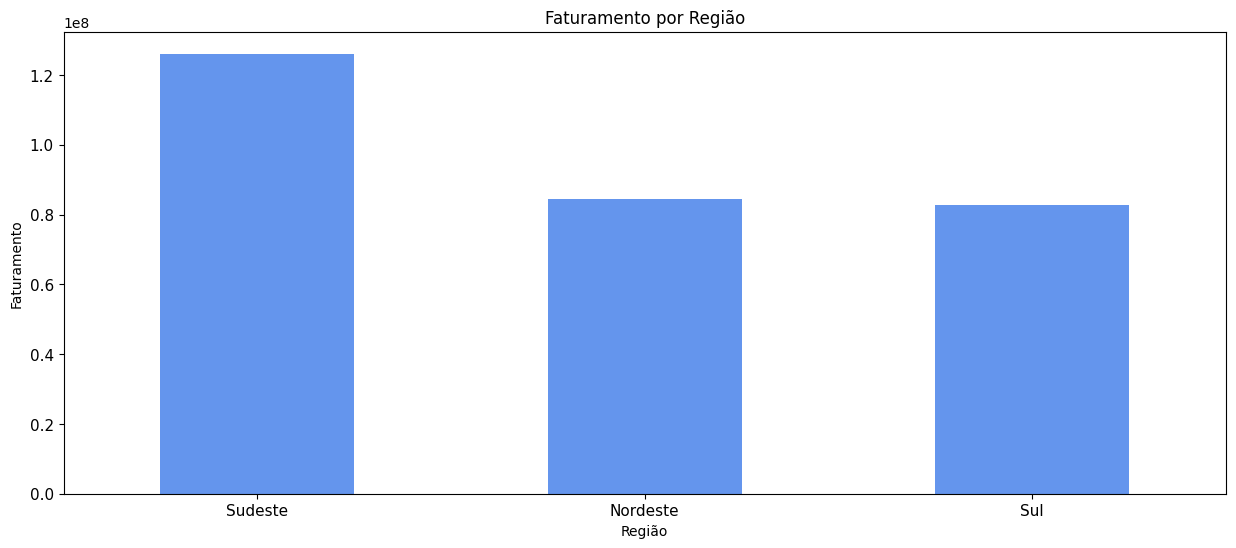

In [228]:
df_vendas_regiao = df_vendas[['Região','Faturamento']].groupby('Região').sum().sort_values('Faturamento', ascending= False).reset_index()
df_vendas_regiao = df_vendas_regiao[df_vendas_regiao['Região'] != 'Online']
df_vendas_regiao.plot(
    kind='bar',
    figsize=(15,6),
    title='Faturamento por Região',
    x = 'Região',
    y = 'Faturamento',
    color='cornflowerblue',
    rot=0,
    legend=False,
    fontsize=11,
    ylabel='Faturamento'
)
df_vendas_regiao['Faturamento'] = df_vendas_regiao['Faturamento'].apply(formatar)
display(df_vendas_regiao)


## Análise 3 - Produtos com maior faturamento

Nesta etapa foi analisado o desempenho financeiro de cada produto considerando todas as vendas registradas na base.

O objetivo é identificar quais produtos geraram maior receita para a empresa, auxiliando na avaliação do portfólio comercial.

In [229]:
faturamento_produtos = df_vendas[['Produto','Faturamento']].groupby('Produto').sum().sort_values('Faturamento', ascending= False).reset_index()
faturamento_produtos['Faturamento'] = faturamento_produtos['Faturamento'].apply(formatar)
display(faturamento_produtos)

,Produto,Faturamento
0,Iphone 14,"R$ 103,510,000.00"
1,Notebook Dell,"R$ 64,599,500.00"
2,Notebook Hp,"R$ 60,476,800.00"
3,Smartphone Samsung,"R$ 40,356,800.00"
4,"Monitor 27""","R$ 22,828,800.00"
5,Teclado Mecânico,"R$ 4,695,750.00"
6,Mouse Gamer,"R$ 2,252,520.00"
7,Cabo Hdmi,"R$ 752,160.00"


## Análise 4 - Produtos com maior faturamento nas vendas online

Para aprofundar a análise do canal digital, foram considerados apenas os pedidos classificados como **Online**.

Os produtos foram agrupados de acordo com o faturamento obtido, permitindo identificar quais itens possuem melhor desempenho especificamente nesse canal de vendas.

In [230]:
analise_vendas_online = df_vendas[df_vendas['forma_venda'] == 'Online']
analise_vendas_online = analise_vendas_online[['Produto','Faturamento']].groupby('Produto').sum().sort_values('Faturamento', ascending= False).reset_index()

analise_vendas_online_formatado = analise_vendas_online.copy()
analise_vendas_online_formatado['Faturamento'] = analise_vendas_online_formatado['Faturamento'].apply(formatar)

display(analise_vendas_online_formatado)

,Produto,Faturamento
0,Iphone 14,"R$ 2,145,000.00"
1,Notebook Hp,"R$ 1,414,400.00"
2,Notebook Dell,"R$ 1,291,500.00"
3,Smartphone Samsung,"R$ 684,200.00"
4,"Monitor 27""","R$ 398,400.00"
5,Teclado Mecânico,"R$ 85,750.00"
6,Mouse Gamer,"R$ 45,480.00"
7,Cabo Hdmi,"R$ 16,120.00"


## Análise 5 - Comparativo entre vendas online e presenciais

Nesta análise foi comparado o faturamento obtido pelos dois canais de venda da empresa: **Online** e **Presencial**.

Além da tabela consolidada, foi gerado um gráfico de barras para facilitar a visualização da participação de cada modalidade no faturamento total.

,forma_venda,Faturamento
0,Presencial,"R$ 293,391,480.00"
1,Online,"R$ 6,080,850.00"


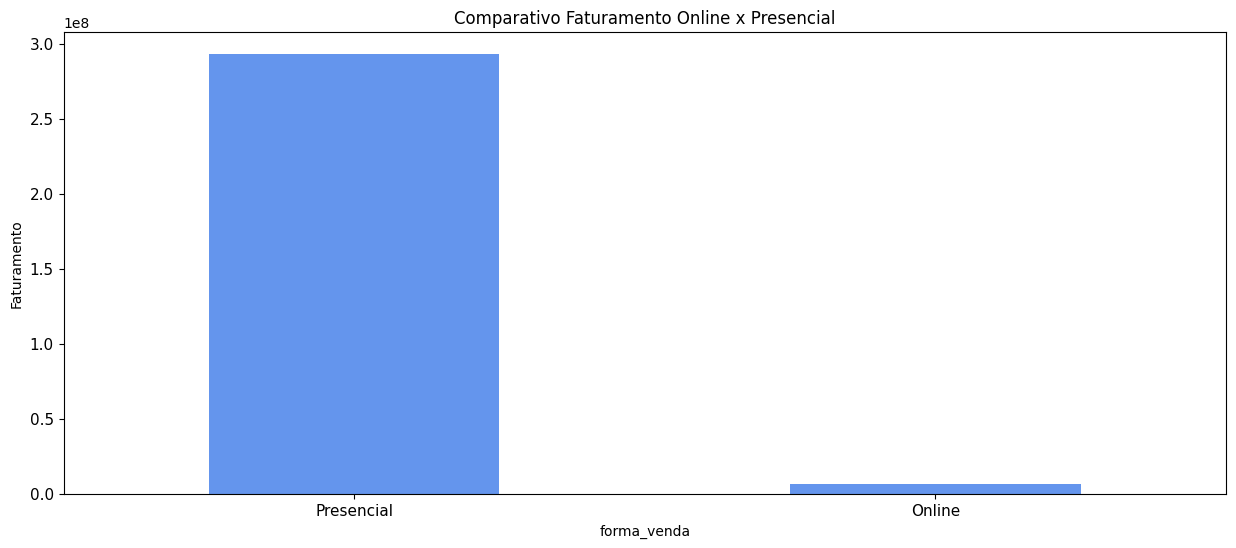

In [231]:
comp_online_presencial = df_vendas[['forma_venda', 'Faturamento']].groupby('forma_venda').sum().sort_values('Faturamento', ascending= False).reset_index()

comp_online_presencial.plot(
    kind='bar',
    figsize=(15,6),
    title='Comparativo Faturamento Online x Presencial',
    x = 'forma_venda',
    y = 'Faturamento',
    color='cornflowerblue',
    rot=0,
    legend=False,
    fontsize=11,
    ylabel='Faturamento'
)

comp_online_presencial['Faturamento'] = comp_online_presencial['Faturamento'].apply(formatar)
display(comp_online_presencial)

## Análise 6 - Desempenho dos gerentes em relação às metas Janeito 2024

Nesta etapa foi avaliado o desempenho dos gerentes durante o mês de **janeiro de 2023**.

Após calcular o faturamento de cada loja no período, os dados foram integrados à base de metas dos gerentes por meio de um **merge**.

Além da identificação das metas alcançadas, foi calculado o percentual de atingimento da meta, permitindo uma avaliação mais detalhada do desempenho de cada gerente.

In [235]:
df_vendas_2023_jan = df_vendas[(df_vendas['Data'].dt.year == 2023) & (df_vendas['Data'].dt.month == 1)]
df_vendas_2023_jan = df_vendas_2023_jan[['Loja', 'Faturamento']].groupby('Loja').sum()


df_vendas_2023_jan = df_vendas_2023_jan.merge(df_gerentes, on= 'Loja').sort_values('Gerente').reset_index()

df_vendas_2023_jan['Status_Meta'] = np.where(df_vendas_2023_jan['Faturamento'] > df_vendas_2023_jan['Meta_Mensal'], 'Meta Alcançada', 'Meta Não Alcançada')
df_vendas_2023_jan['%_Meta'] = (df_vendas_2023_jan['Faturamento'] /df_vendas_2023_jan['Meta_Mensal']).map('{:.2%}'.format)

display(df_vendas_2023_jan)

,index,Loja,Faturamento,Gerente,Meta_Mensal,Status_Meta,%_Meta
0,5,Salvador,1686070.0,Ana,52000,Meta Alcançada,3242.44%
1,6,São Paulo,1831140.0,Carlos,50000,Meta Alcançada,3662.28%
2,4,Rio De Janeiro,1736830.0,Fernanda,60000,Meta Alcançada,2894.72%
3,0,Belo Horizonte,1779100.0,Juliana,55000,Meta Alcançada,3234.73%
4,3,Recife,1779020.0,Marcos,48000,Meta Alcançada,3706.29%
5,2,Porto Alegre,1726640.0,Pedro,42000,Meta Alcançada,4111.05%
6,1,Curitiba,1986920.0,Roberto,45000,Meta Alcançada,4415.38%


## 📊 Análise 7 - Evolução do faturamento ao longo do tempo

Como etapa final, foi elaborado um gráfico apresentando a evolução do faturamento por período.

Essa visualização permite identificar tendências, sazonalidades e possíveis variações no desempenho das vendas ao longo do tempo.

<Axes: title={'center': 'Faturamento por Ano'}, xlabel='Data-Ano', ylabel='Faturamento'>

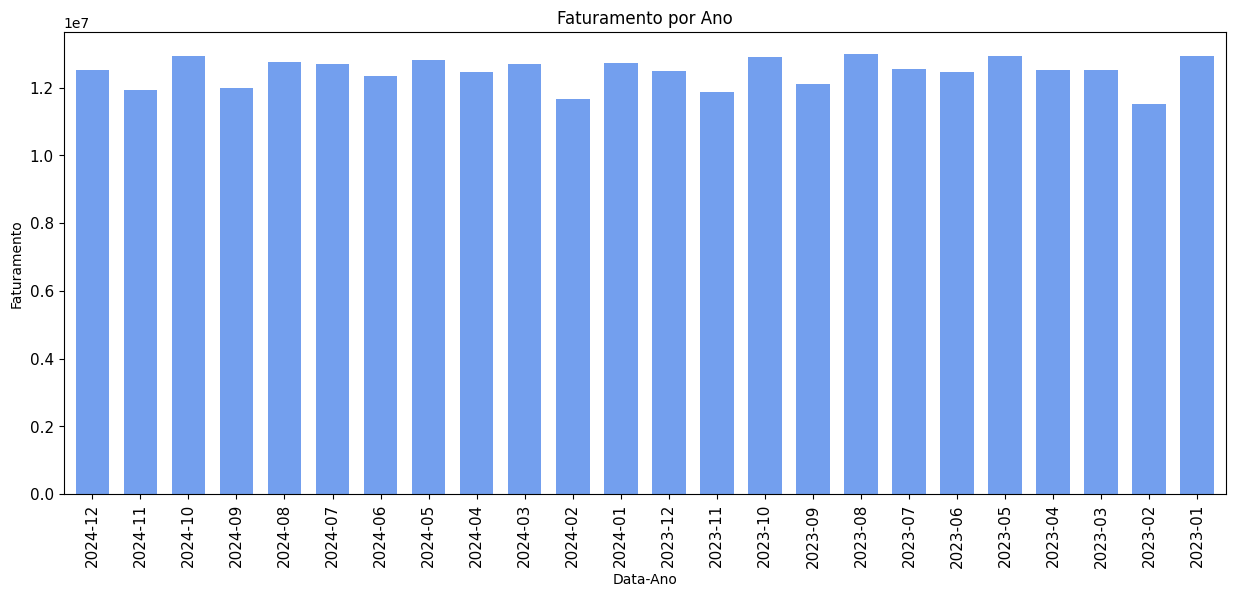

In [233]:
from numpy._core.defchararray import index
#grafico de vendas

df_vendas['Data-Ano'] = df_vendas['Data'].dt.to_period('M')
df_vendas_ano = df_vendas[['Data-Ano','Faturamento']].groupby('Data-Ano').sum().sort_values('Data-Ano', ascending= False)

df_vendas_ano.plot(
    kind='bar',
    figsize=(15,6),
    title='Faturamento por Ano',
    color='cornflowerblue',
    width=0.7,
    alpha=0.9,
    legend=False,
    fontsize=11,
    ylabel='Faturamento'
)


## ✅ Conclusão

Ao longo deste projeto foi desenvolvido um processo completo de **ETL (Extract, Transform and Load)** utilizando Python e Pandas, contemplando desde a extração dos dados até a geração de análises e indicadores.

Durante o desenvolvimento foram aplicadas técnicas de limpeza, padronização, enriquecimento da base, integração entre diferentes fontes de dados, exportação de subconjuntos e construção de análises gerenciais. Como resultado, foi obtida uma base de dados tratada, estruturada e pronta para apoiar processos de tomada de decisão e servir como fonte para ferramentas de Business Intelligence.